# 03 - Feature Engineering
Feature transformations and encodings.

In [24]:
import pandas as pd
import numpy as np

In [25]:
import sys
from pathlib import Path

venv_site_packages = Path(r"C:\Aman\Project\customer-churn-prediction\venv\Lib\site-packages")

if str(venv_site_packages) not in sys.path:
    sys.path.insert(0, str(venv_site_packages))

import pandas as pd

In [26]:
file_path = Path(r"C:\Aman\Project\customer-churn-prediction\data\raw\Telco_customer_churn.xlsx")
df = pd.read_excel(file_path)

In [27]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [28]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

df = df.drop(columns=drop_cols)

In [29]:
df.to_csv("../data/processed/churn_cleaned.csv", index=False)

In [30]:
df_saved = pd.read_csv("../data/processed/churn_cleaned.csv")

df_saved.shape

(7043, 20)

In [31]:
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

In [32]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [33]:
df['Total Charges'].head()

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
Name: Total Charges, dtype: object

In [34]:
df['Total Charges'].unique()[:10]

array([108.15, 151.65, 820.5, 3046.05, 5036.3, 528.35, 39.65, 20.15,
       4749.15, 30.2], dtype=object)

In [35]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [36]:
df['Total Charges'].dtype

dtype('float64')

In [37]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [38]:
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

In [39]:
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

In [40]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='str')

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or str(X[col].dtype) == 'str':
        X[col] = le.fit_transform(X[col].astype(str))

In [43]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   int64  
 1   Senior Citizen     7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   int64  
 7   Internet Service   7043 non-null   int64  
 8   Online Security    7043 non-null   int64  
 9   Online Backup      7043 non-null   int64  
 10  Device Protection  7043 non-null   int64  
 11  Tech Support       7043 non-null   int64  
 12  Streaming TV       7043 non-null   int64  
 13  Streaming Movies   7043 non-null   int64  
 14  Contract           7043 non-null   int64  
 15  Paperless Billing  7043 non-null   int64  
 16  Payment Method     7043 non-null   

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Aman\Project\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.8048261178140526


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.65      0.59      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Logistic Regression Results

The Logistic Regression model achieved an accuracy of approximately 80%.

### Classification Performance

- Non-Churn customers:
  - Precision: 86%
  - Recall: 88%
  - F1-score: 87%

- Churn customers:
  - Precision: 65%
  - Recall: 59%
  - F1-score: 61%

### Observations

The model performs well in identifying customers who remain with the company.

However, churn prediction performance is lower, with only 59% of churning customers correctly identified.

This indicates that while the model provides a strong baseline, more advanced models may improve churn detection performance.

## Logistic Regression

A Logistic Regression model was trained as the baseline classification model.

### Results

- Accuracy: 80.48%
- Churn Precision: 65%
- Churn Recall: 59%
- Churn F1-Score: 61%

### Observations

The model achieved the highest overall performance among the tested models.

It correctly identified 59% of customers who eventually churned while maintaining strong overall accuracy.

This model provides a good balance between accuracy and churn detection performance and serves as a strong baseline for comparison with more complex models.

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7267565649396736
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



## Decision Tree Classifier

A Decision Tree classifier was trained to learn decision rules from customer attributes.

### Results

- Accuracy: 72.68%
- Churn Precision: 49%
- Churn Recall: 51%
- Churn F1-Score: 50%

### Observations

The Decision Tree model produced lower performance compared to Logistic Regression.

Although it was able to identify some churn patterns, its overall accuracy and churn prediction capability were weaker.

The model appears to overfit the training data and does not generalize as effectively to unseen customers.

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.794889992902768
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



## Random Forest Classifier

A Random Forest classifier was trained using an ensemble of multiple decision trees.

### Results

- Accuracy: 79.49%
- Churn Precision: 64%
- Churn Recall: 52%
- Churn F1-Score: 57%

### Observations

The Random Forest model achieved strong overall accuracy and improved stability compared to a single Decision Tree.

However, its ability to identify churning customers remained lower than Logistic Regression.

While the model performed well for non-churn customers, it missed a larger proportion of churn cases.

In [50]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
18,Total Charges,0.179892
17,Monthly Charges,0.173788
4,Tenure Months,0.155685
14,Contract,0.080227
8,Online Security,0.049891
16,Payment Method,0.049608
11,Tech Support,0.041774
3,Dependents,0.037298
0,Gender,0.027349
9,Online Backup,0.027084


## Feature Importance Analysis

The Random Forest model was used to identify the most influential features affecting customer churn.

### Top Features

1. Total Charges
2. Monthly Charges
3. Tenure Months
4. Contract Type
5. Online Security
6. Payment Method
7. Tech Support

### Observations

Customer financial information and service duration were the strongest predictors of churn.

Customers with higher monthly costs, specific contract types, and shorter tenure showed a greater tendency to leave the company.

Support-related services such as Online Security and Tech Support also played an important role in customer retention.

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7877927608232789
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that combines multiple weak learners to improve prediction performance.

It is widely used in classification and prediction tasks due to its ability to handle complex patterns and feature interactions.

### Results

- Accuracy: 78.78%
- Churn Precision: 61%
- Churn Recall: 55%
- Churn F1-Score: 58%

### Observations

The XGBoost model achieved strong overall performance but did not outperform the Logistic Regression model on this dataset.

While the model was able to identify a significant portion of churning customers, its recall and F1-score were lower than those achieved by Logistic Regression.

### Conclusion

Although XGBoost is a powerful ensemble algorithm, it was not the best-performing model for this specific churn prediction problem.

The results suggest that the relationship between customer attributes and churn may be relatively linear, allowing Logistic Regression to perform competitively while remaining simpler and more interpretable.

# Model Comparison

| Model | Accuracy | Churn Precision | Churn Recall | Churn F1 |
|---------|---------|---------|---------|---------|
| Logistic Regression | 80.48% | 65% | 59% | 61% |
| Decision Tree | 72.68% | 49% | 51% | 50% |
| Random Forest | 79.49% | 64% | 52% | 57% |
| XGBoost | 78.78% | 61% | 55% | 58% |

## Best Model

Based on overall performance, Logistic Regression was selected as the final model.

### Reasons

- Highest accuracy among all tested models.
- Highest churn recall.
- Highest churn F1-score.
- Simpler and more interpretable than ensemble models.
- Faster training and easier deployment.

## Final Conclusion

Logistic Regression demonstrated the strongest balance between predictive performance and model simplicity. Therefore, it was chosen as the final model for deployment in the Customer Churn Prediction Dashboard.

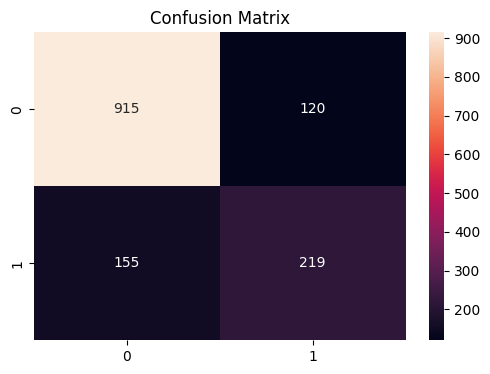

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.show()

## Confusion Matrix

The confusion matrix provides a detailed view of the model's prediction performance.

| Metric | Count |
|----------|----------|
| True Negatives | 915 |
| False Positives | 120 |
| False Negatives | 155 |
| True Positives | 219 |

### Observations

- The model correctly identified 915 customers who did not churn.
- The model correctly identified 219 customers who churned.
- 120 customers were incorrectly predicted as churning.
- 155 churning customers were missed by the model.

The model performs well in identifying non-churning customers while maintaining a reasonable ability to detect churning customers.

In [54]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.8483272623937586

## ROC-AUC Score

The Receiver Operating Characteristic - Area Under Curve (ROC-AUC) score evaluates the model's ability to distinguish between churn and non-churn customers.

### Result

ROC-AUC Score: **0.848**

### Interpretation

A ROC-AUC score of 0.848 indicates strong discriminative performance. The model can effectively separate customers likely to churn from those likely to remain with the company.

### Conclusion

The Logistic Regression model demonstrates strong predictive capability and provides a good balance between performance and interpretability, making it suitable for customer churn prediction.